# Recomendacao Ecommerce - Analysis Notebook

## Objetivo
Gerar ranking de itens mais provaveis de compra para aumentar conversao.

## Perguntas de negocio
- Qual ganho real de HitRate e MRR?
- Quais itens aparecem demais e podem reduzir diversidade?
- Como personalizar mantendo cobertura do catalogo?


### O que este código faz
Carrega bibliotecas, lê os arquivos principais do projeto (`data` e `metrics`) e mostra uma primeira amostra dos dados para conferência inicial.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path('..')
data_path = project_root / 'data' / 'interactions_synthetic.csv'
metrics_path = project_root / 'models' / 'metrics.json'

pd.set_option('display.max_columns', 200)
df = pd.read_csv(data_path)
metrics = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.exists() else {}

print('shape:', df.shape)
print('metrics keys:', list(metrics.keys()))
df.head(5)


shape: (22957, 5)
metrics keys: ['selected_model', 'evaluation_users', 'hit_rate_at_10', 'mrr_at_10', 'baseline_hit_rate_at_10', 'baseline_mrr_at_10', 'advanced_hit_rate_at_10', 'advanced_mrr_at_10', 'xgboost_available', 'used_optuna', 'reports_generated']


,user_id,item_id,event_type,event_weight,timestamp
0,U0311,I0161,view,1.0,2025-09-01
1,U0096,I0121,cart,3.0,2025-09-01
2,U0262,I0136,purchase,7.0,2025-09-01
3,U0288,I0108,view,1.0,2025-09-01
4,U0420,I0108,view,1.0,2025-09-01


### O que este código faz
Verifica qualidade básica dos dados: valores ausentes e distribuição da variável-alvo (quando existir). É um check rápido antes de qualquer análise.


In [2]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('missing columns:', len(missing))
if len(missing) > 0:
    display(missing)

if 'event_type' in df.columns:
    print('target distribution:')
    print(df['event_type'].value_counts(normalize=True).round(4))


missing columns: 0
target distribution:
event_type
view        0.3930
cart        0.3258
purchase    0.2813
Name: proportion, dtype: float64


### O que este código faz
Realiza uma análise exploratória específica do projeto para gerar visão inicial dos padrões principais.


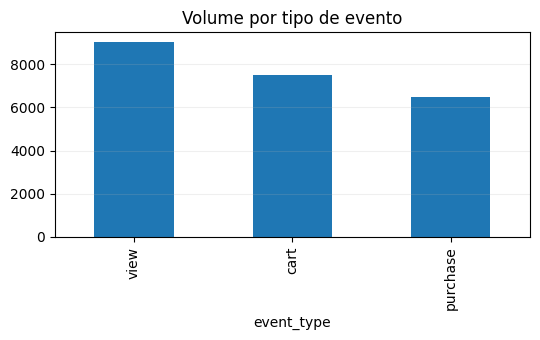

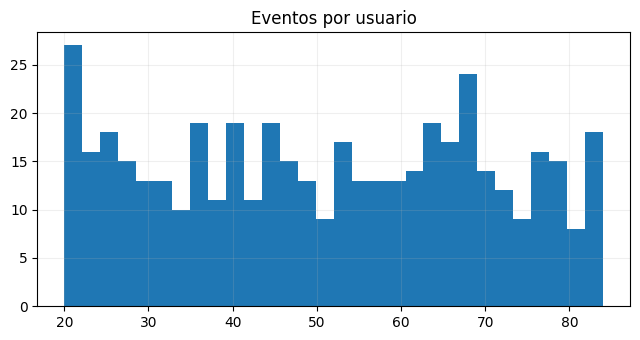

In [3]:
event_counts = df['event_type'].value_counts()
plt.figure(figsize=(5.5, 3.5))
event_counts.plot(kind='bar')
plt.title('Volume por tipo de evento')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

user_activity = df.groupby('user_id').size()
plt.figure(figsize=(6.5, 3.5))
plt.hist(user_activity, bins=30)
plt.title('Eventos por usuario')
plt.grid(alpha=0.2)
plt.tight_layout()


### O que este código faz
Gera visualizações complementares para facilitar interpretação e comunicação dos resultados.


In [4]:
reco_path = project_root / 'data' / 'recommendations_top10.csv'
if reco_path.exists():
    reco = pd.read_csv(reco_path)
    print('recommendations shape:', reco.shape)
    top_items = reco['item_id'].value_counts().head(15)
    display(top_items)
else:
    print('recommendations_top10.csv nao encontrado')


recommendations shape: (4500, 3)


item_id
I0060    91
I0096    56
I0177    51
I0028    50
I0141    49
I0018    45
I0120    44
I0039    44
I0054    44
I0157    44
I0172    42
I0010    41
I0092    40
I0105    40
I0077    40
Name: count, dtype: int64

### O que este código faz
Exibe as métricas salvas no pipeline para conectar análise exploratória com desempenho final do modelo.


In [5]:
pd.DataFrame([metrics]).T.rename(columns={0: 'value'}).head(30)


,value
selected_model,item_item_cosine
evaluation_users,450
hit_rate_at_10,0.1333
mrr_at_10,0.0531
baseline_hit_rate_at_10,0.1333
baseline_mrr_at_10,0.0531
advanced_hit_rate_at_10,None
advanced_mrr_at_10,None
xgboost_available,False
used_optuna,False


## Status atual
- Este projeto ja foi executado de ponta a ponta.
- Artefatos (dados, modelos, metricas e relatorios) estao gerados.
- Repositorio publicado e sincronizado no GitHub.
